# Quantis — Exploratory Data Analysis

Exploration of the cleaned dataset built by `src/data.py` (10 years of daily
OHLCV for 8 stocks). This notebook is for *exploration only* — the pipeline in
`src/` is the source of truth. Run from the `notebooks/` folder.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25

df = pd.read_csv('../data/processed/dataset.csv', parse_dates=['Date'])
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,log_return,target,ticker,ticker_id,shariah_status
0,2016-06-21,23.735001,24.087500,23.6700,23.977501,21.833878,142185600,0.008481,-0.003760,AAPL,0,shariah
1,2016-06-22,24.062500,24.222500,23.8375,23.887501,21.751926,116876400,-0.003760,0.005739,AAPL,0,shariah
2,2016-06-23,23.985001,24.072500,23.8125,24.025000,21.877125,128960800,0.005739,-0.028498,AAPL,0,shariah
3,2016-06-24,23.227501,23.665001,23.1625,23.350000,21.262478,301245600,-0.028498,-0.014668,AAPL,0,shariah
4,2016-06-27,23.250000,23.262501,22.8750,23.010000,20.952873,181958400,-0.014668,0.016700,AAPL,0,shariah


## 1. Dataset overview

How many rows, which tickers, what date range, and the Shariah tags.


In [2]:
print('rows x cols :', df.shape)
print('tickers     :', sorted(df['ticker'].unique()))
print('date range  :', df['Date'].min().date(), '->', df['Date'].max().date())
print('shariah tags:', df.groupby('shariah_status')['ticker'].unique().to_dict())
df[['log_return', 'target', 'Volume']].describe()

rows x cols : (20096, 12)
tickers     : ['AAPL', 'AMZN', 'JNJ', 'JPM', 'META', 'MSFT', 'TSLA', 'XOM']
date range  : 2016-06-21 -> 2026-06-17
shariah tags: {'conventional': array(['JPM'], dtype=object), 'shariah': array(['AAPL', 'META'], dtype=object), 'unclassified': array(['AMZN', 'JNJ', 'MSFT', 'TSLA', 'XOM'], dtype=object)}


,log_return,target,Volume
count,20096.000000,20096.000000,2.009600e+04
mean,0.000764,0.000761,4.610653e+07
std,0.021736,0.021739,5.295104e+07
min,-0.306391,-0.306391,2.114900e+06
25%,-0.008036,-0.008047,1.232298e+07
50%,0.000855,0.000854,2.425695e+07
75%,0.010281,0.010286,6.407655e+07
max,0.209308,0.209308,9.140820e+08


## 2. Per-ticker summary

Sample count, coverage, average daily return and annualised volatility per stock.


In [3]:
summary = df.groupby('ticker').agg(
    days=('Date', 'size'),
    start=('Date', 'min'),
    end=('Date', 'max'),
    mean_daily_ret=('log_return', 'mean'),
    daily_vol=('log_return', 'std'),
)
summary['annual_vol'] = summary['daily_vol'] * np.sqrt(252)
summary

,days,start,end,mean_daily_ret,daily_vol,annual_vol
ticker,,,,,,
AAPL,2512,2016-06-21,2026-06-17,0.001041,0.018201,0.288935
AMZN,2512,2016-06-21,2026-06-17,0.000754,0.020463,0.324834
JNJ,2512,2016-06-21,2026-06-17,0.000387,0.011668,0.185216
JPM,2512,2016-06-21,2026-06-17,0.000773,0.017254,0.273902
META,2512,2016-06-21,2026-06-17,0.000645,0.024646,0.391236
MSFT,2512,2016-06-21,2026-06-17,0.000855,0.017077,0.271082
TSLA,2512,2016-06-21,2026-06-17,0.001313,0.037156,0.589834
XOM,2512,2016-06-21,2026-06-17,0.000346,0.017803,0.282621


## 3. Normalised price history

Each stock indexed to 100 at the start, so they're comparable on one chart.


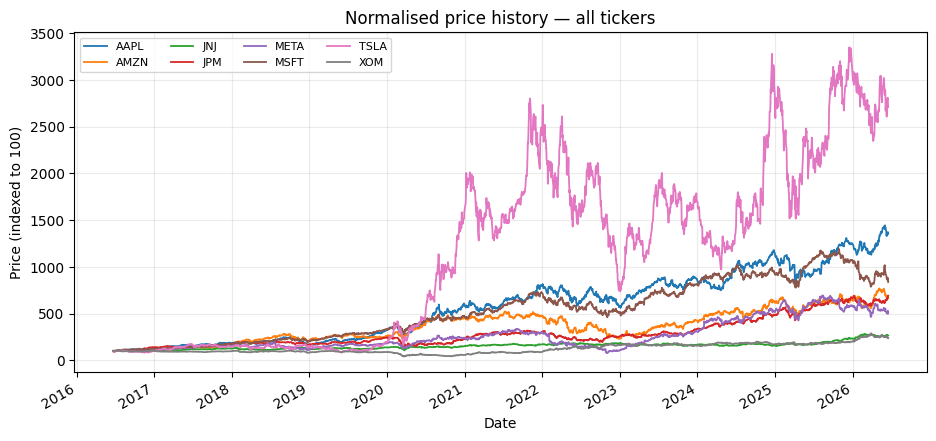

In [4]:
pivot = df.pivot_table(index='Date', columns='ticker', values='Adj Close')
normed = pivot / pivot.iloc[0] * 100
normed.plot(lw=1.3)
plt.ylabel('Price (indexed to 100)')
plt.title('Normalised price history — all tickers')
plt.legend(ncol=4, fontsize=8)
plt.show()

## 4. Daily return distributions

Returns are roughly bell-shaped and centred near zero, with fat tails — the
reason next-day *direction* is so hard to predict.


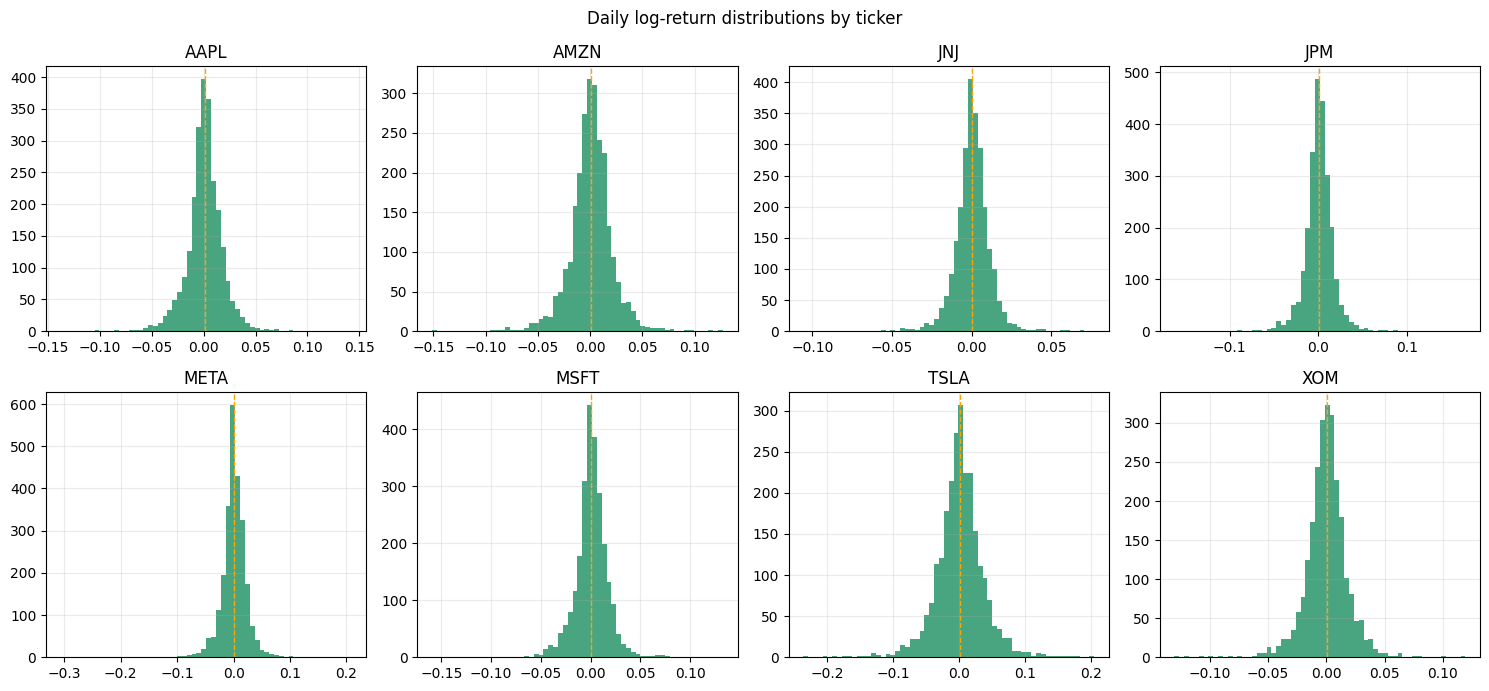

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(15, 7))
for ax, t in zip(axes.ravel(), sorted(df['ticker'].unique())):
    r = df.loc[df['ticker'] == t, 'log_return']
    ax.hist(r, bins=60, color='#1A8F5F', alpha=0.8)
    ax.axvline(r.mean(), color='orange', ls='--', lw=1)
    ax.set_title(t)
fig.suptitle('Daily log-return distributions by ticker')
fig.tight_layout()
plt.show()

## 5. Return correlation across tickers

How the stocks move together day-to-day (greener = more correlated).


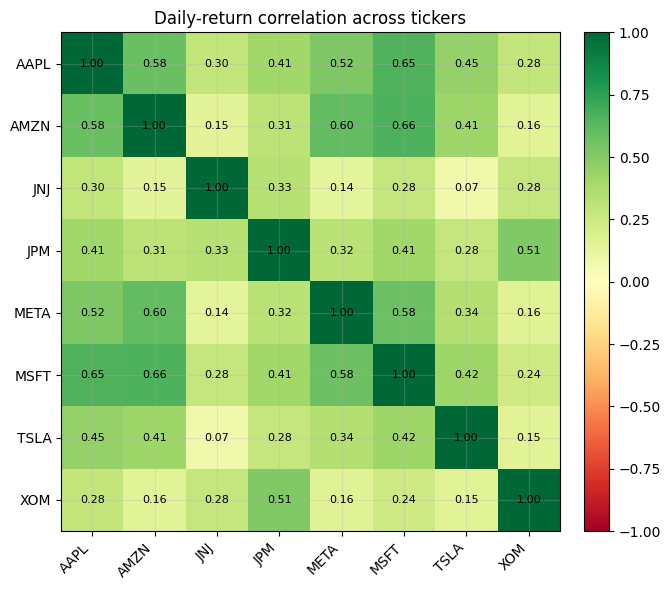

In [6]:
corr = df.pivot_table(index='Date', columns='ticker', values='log_return').corr()
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr.values, cmap='RdYlGn', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr)), corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.values[i, j]:.2f}', ha='center', va='center', fontsize=8)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title('Daily-return correlation across tickers')
fig.tight_layout()
plt.show()

---
**Takeaways:** prices trend over years but daily returns are near-zero-mean with
fat tails and only moderate cross-stock correlation — consistent with the
project's finding that next-day direction is close to unpredictable.
